In [1]:
!nvidia-smi

Mon May 13 19:24:41 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 530.30.02              Driver Version: 530.30.02    CUDA Version: 12.1     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                  Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf            Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla V100-PCIE-32GB            On | 00000000:3B:00.0 Off |                    0 |
| N/A   25C    P0               24W / 250W|      0MiB / 32768MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [2]:
!git clone https://github.com/bowang-lab/MedSAM


fatal: destination path 'MedSAM' already exists and is not an empty directory.


In [2]:
from pathlib import Path
import os 


In [3]:

# define dataset path
BASE_PATH = Path('./').resolve()
DATA_PATH = BASE_PATH / 'dataset'

In [4]:
os.chdir(BASE_PATH)
os.getcwd()

os.chdir('MedSAM')
os.getcwd()

!pip install -e .

os.chdir(BASE_PATH)
os.getcwd()

Obtaining file:///beegfs/data/work/shared/ngmm/scripts/Taiabur/medSAM/MedSAM
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.3/516.3 kB 8.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.4/139.4 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 93.0 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 95.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.2/133.2 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.3/383.3 kB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 37.0 MB/s 

'/beegfs/data/work/shared/ngmm/scripts/Taiabur/medSAM'

In [1]:
import zipfile
import os

def unzip_folder(zip_path, extract_to):
    """
    Unzip a folder.

    Args:
    - zip_path: Path to the zip file.
    - extract_to: Directory to extract the contents of the zip file to.
    """
    # Create the directory to extract to if it doesn't exist
    if not os.path.exists(extract_to):
        os.makedirs(extract_to)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

    print("Folder unzipped successfully!")

# Example usage:
zip_file_path = "/user1/ngmm/tr855969/Desktop/Taiabur/medSAM/MedSAM/data/FLARE22Train.zip"
extract_to_directory = "/user1/ngmm/tr855969/Desktop/Taiabur/medSAM/MedSAM/data/"

unzip_folder(zip_file_path, extract_to_directory)


Folder unzipped successfully!


Shape of the image array: (1024, 1024)


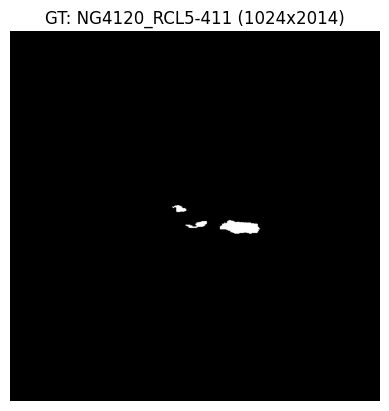

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Load the .npy file
file_path = '/user1/ngmm/tr855969/Desktop/Taiabur/medSAM/MedSAM/data/npy/MB_Nabd/gts/MB_Nabd_NG4120_RCL5-411.npy'
image_array = np.load(file_path)

# Display the shape of the array
print("Shape of the image array:", image_array.shape)

# Display the image using matplotlib
plt.imshow(image_array, cmap='gray')  # Assuming grayscale image, change cmap if needed
plt.axis('off')  # Turn off axis
plt.title('GT: NG4120_RCL5-411 (1024x2014)')
plt.show()


In [21]:
def numpyfilesdisplay(file_path, filename):
    
    image_array = np.load(file_path)

    # Display the shape of the array
    print("Shape of the image array:", image_array.shape)

    # Display the image using matplotlib
    plt.imshow(image_array, cmap='gray')  # Assuming grayscale image, change cmap if needed
    plt.axis('off')  # Turn off axis
    plt.title(f'{filename} (1024x2014)')
    plt.show()


Shape of the image data: (361, 780, 412)


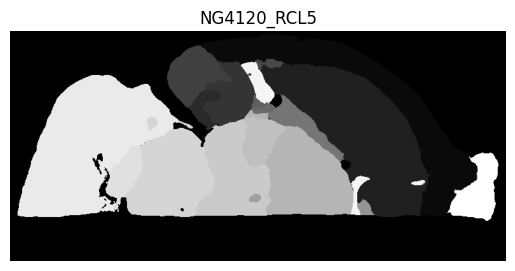

In [4]:
import nibabel as nib
import matplotlib.pyplot as plt

# Load the .nii.gz file
file_path = '/user1/ngmm/tr855969/Desktop/Taiabur/medSAM/MedSAM/data/npy/MB_Nabd/MB_Nabd_NG4120_RCL5_gt.nii.gz'
img = nib.load(file_path)

# Get the image data
img_data = img.get_fdata()

# Display the shape of the image data
print("Shape of the image data:", img_data.shape)

# Display the image using matplotlib
plt.imshow(img_data[:, :, img_data.shape[2] // 2], cmap='gray')  # Display the middle slice
plt.axis('off')  # Turn off axis
plt.title('NG4120_RCL5')
plt.show()


Shape of the image data: (361, 780, 412)


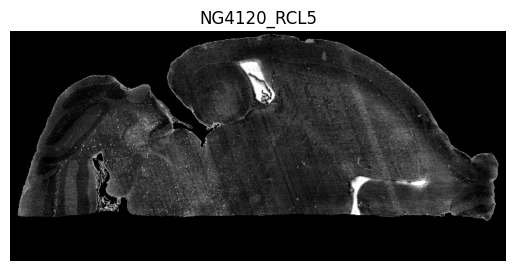

In [6]:
import nibabel as nib
import matplotlib.pyplot as plt

# Load the .nii.gz file
file_path = '/user1/ngmm/tr855969/Desktop/Taiabur/medSAM/MedSAM/data/npy/MB_Nabd/MB_Nabd_NG4120_RCL5_img.nii.gz'
img = nib.load(file_path)

# Get the image data
img_data = img.get_fdata()

# Display the shape of the image data
print("Shape of the image data:", img_data.shape)

# Display the image using matplotlib
plt.imshow(img_data[:, :, img_data.shape[2] // 2], cmap='gray')  # Display the middle slice
plt.axis('off')  # Turn off axis
plt.title('NG4120_RCL5')
plt.show()


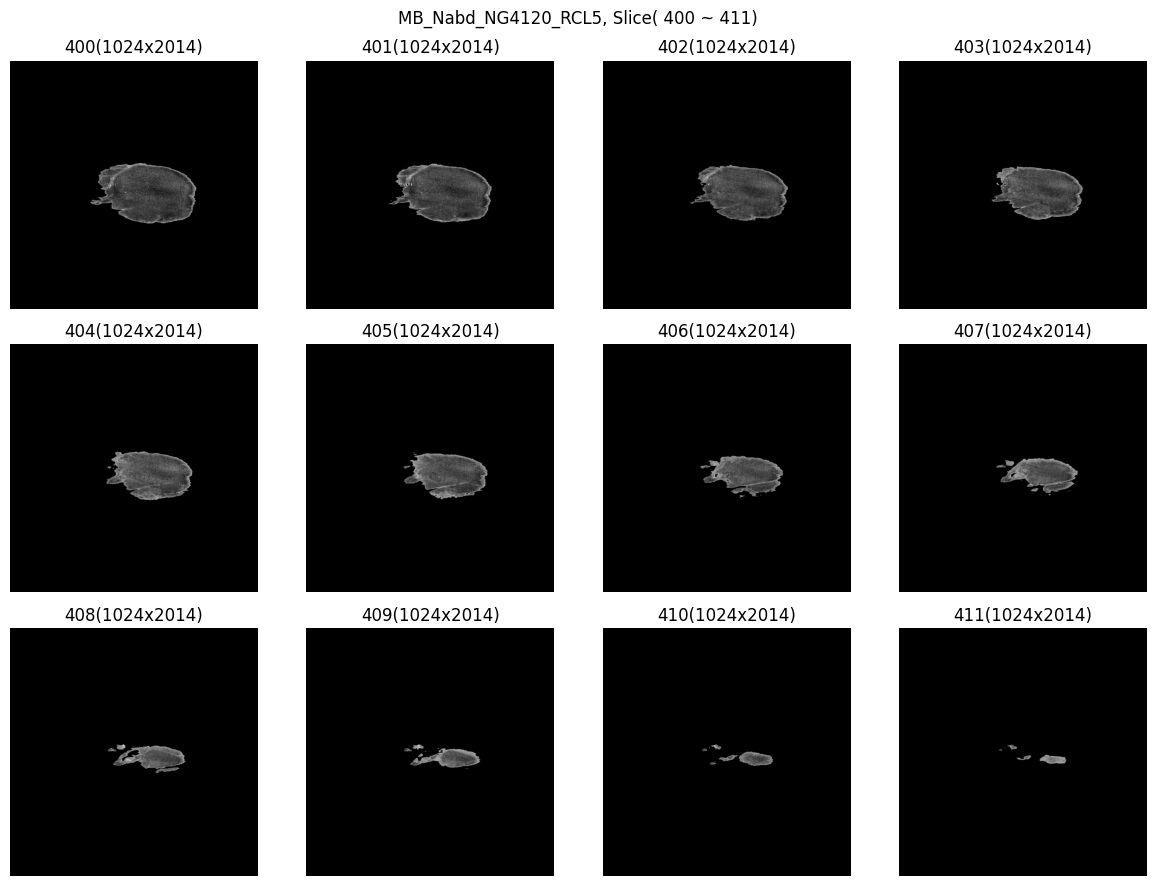

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def numpyfilesdisplay(file_path, filename):
    image_array = np.load(file_path)
    return image_array

# Create a subplot grid
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 9))

# Loop through the images and display them in the subplot grid
for i, ax in zip(range(400, 412), axes.flat):
    filename = f"MB_Nabd_NG4120_RCL5-{i}"
    # /user1/ngmm/tr855969/Desktop/Taiabur/medSAM/MedSAM/data/npy/MB_Nabd/imgs/MB_Nabd_NG4120_RCL5-410.npy
    file_path = f'/user1/ngmm/tr855969/Desktop/Taiabur/medSAM/MedSAM/data/npy/MB_Nabd/imgs/{filename}.npy'
    
    image_array = numpyfilesdisplay(file_path, filename)
    
    # Display the image
    ax.imshow(image_array, cmap='gray')
    ax.axis('off')
    ax.set_title(f'{i}(1024x2014)')
    ax.set_xlabel(filename)

# Adjust layout
plt.suptitle("MB_Nabd_NG4120_RCL5, Slice( 400 ~ 411)")
plt.tight_layout()
plt.show()


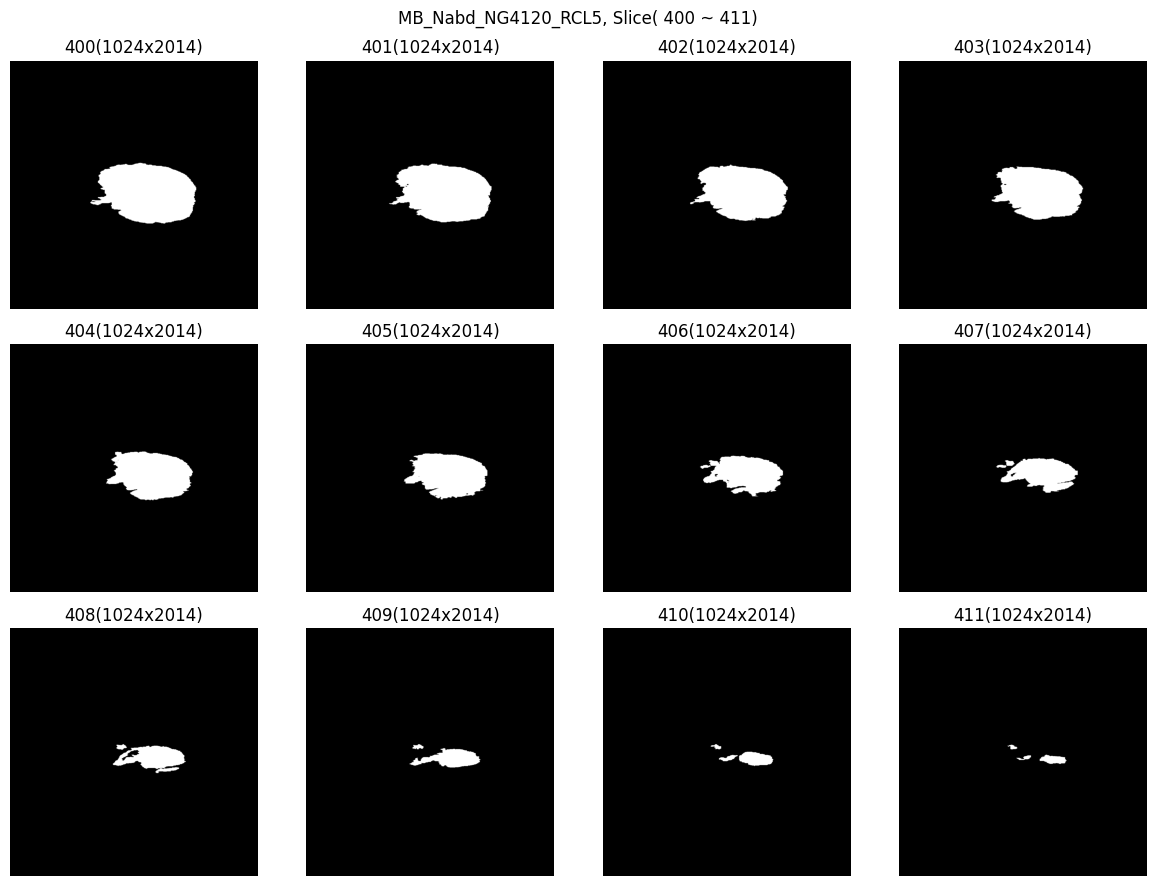

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def numpyfilesdisplay(file_path, filename):
    image_array = np.load(file_path)
    return image_array

# Create a subplot grid
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 9))

# Loop through the images and display them in the subplot grid
for i, ax in zip(range(400, 412), axes.flat):
    filename = f"MB_Nabd_NG4120_RCL5-{i}"
    file_path = f'/user1/ngmm/tr855969/Desktop/Taiabur/medSAM/MedSAM/data/npy/MB_Nabd/gts/{filename}.npy'
    
    image_array = numpyfilesdisplay(file_path, filename)
    
    # Display the image
    ax.imshow(image_array, cmap='gray')
    ax.axis('off')
    ax.set_title(f'{i}(1024x2014)')
    ax.set_xlabel(filename)

# Adjust layout
plt.suptitle("MB_Nabd_NG4120_RCL5, Slice( 400 ~ 411)")
plt.tight_layout()
plt.show()


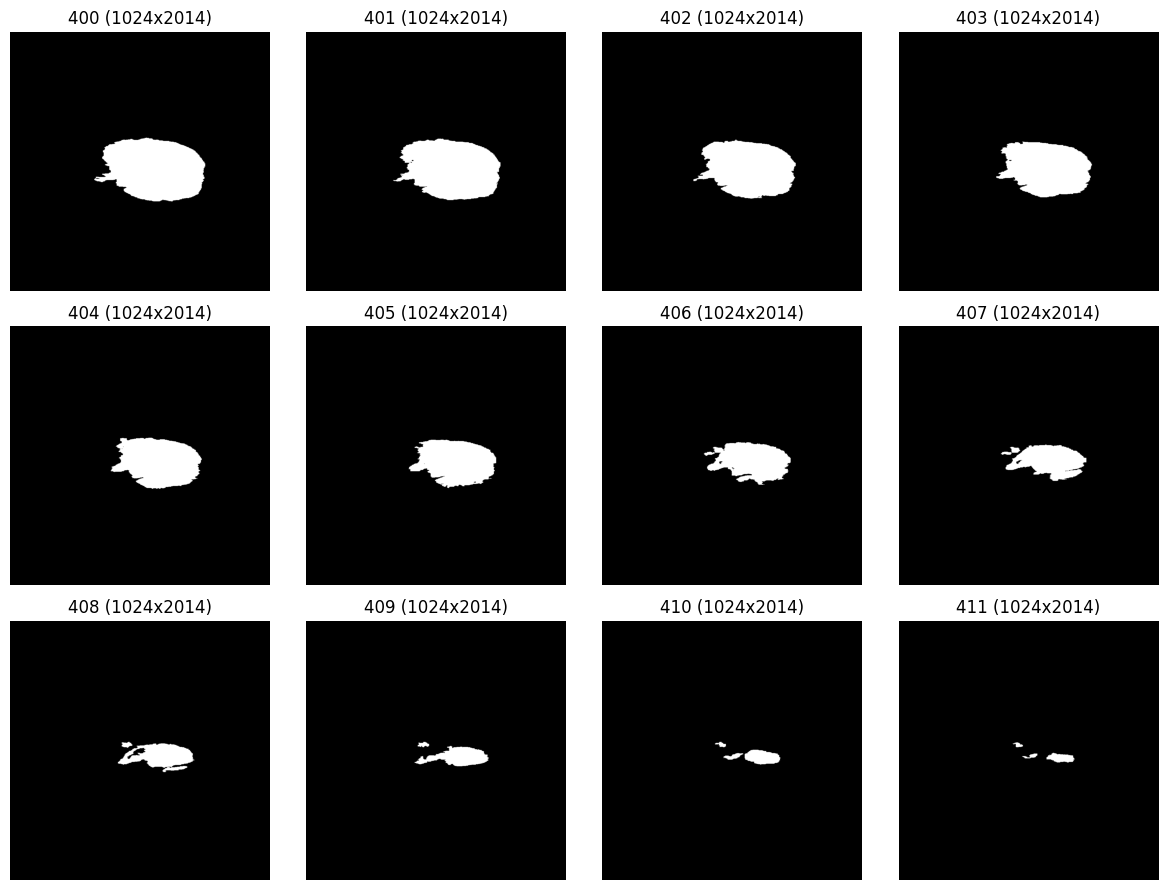

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def numpyfilesdisplay(file_path, filename):
    image_array = np.load(file_path)
    return image_array

# Create a subplot grid
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 9))

# Loop through the images and display them in the subplot grid
for i, ax in zip(range(400, 412), axes.flat):
    filename = f"MB_Nabd_NG4120_RCL5-{i}"
    file_path = f'/user1/ngmm/tr855969/Desktop/Taiabur/medSAM/MedSAM/data/npy/MB_Nabd/gts/{filename}.npy'
    
    image_array = numpyfilesdisplay(file_path, filename)
    
    # Display the image
    ax.imshow(image_array, cmap='gray')
    ax.axis('off')
    ax.set_title(f'{i} (1024x2014)')

# Adjust layout
plt.tight_layout()
plt.show()


In [7]:
# %% set up environment
import numpy as np
import matplotlib.pyplot as plt
import os
join = os.path.join
from tqdm import tqdm
import torch
from torch.utils.data import Dataset, DataLoader
import monai
from segment_anything import SamPredictor, sam_model_registry
from segment_anything.utils.transforms import ResizeLongestSide
from MedSAM.utils.SurfaceDice import compute_dice_coefficient
# set seeds
torch.manual_seed(2023)
np.random.seed(2023)

2024-05-13 19:26:30.804840: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-05-13 19:26:30.807947: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-05-13 19:26:30.856025: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-13 19:26:30.856054: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-13 19:26:30.857523: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [8]:
#%% create a dataset class to load npz data and return back image embeddings and ground truth
class NpzDataset(Dataset): 
    def __init__(self, data_root):
        self.data_root = data_root
        self.npz_files = sorted(os.listdir(self.data_root)) 
        self.npz_data = [np.load(join(data_root, f)) for f in self.npz_files]
        # this implementation is ugly but it works (and is also fast for feeding data to GPU) if your server has enough RAM
        # as an alternative, you can also use a list of npy files and load them one by one
        self.ori_gts = np.vstack([d['gts'] for d in self.npz_data])
        self.img_embeddings = np.vstack([d['img_embeddings'] for d in self.npz_data])
        print(f"{self.img_embeddings.shape=}, {self.ori_gts.shape=}")
    
    def __len__(self):
        return self.ori_gts.shape[0]

    def __getitem__(self, index):
        img_embed = self.img_embeddings[index]
        gt2D = self.ori_gts[index]
        y_indices, x_indices = np.where(gt2D > 0)
        x_min, x_max = np.min(x_indices), np.max(x_indices)
        y_min, y_max = np.min(y_indices), np.max(y_indices)
        # add perturbation to bounding box coordinates
        H, W = gt2D.shape
        x_min = max(0, x_min - np.random.randint(0, 20))
        x_max = min(W, x_max + np.random.randint(0, 20))
        y_min = max(0, y_min - np.random.randint(0, 20))
        y_max = min(H, y_max + np.random.randint(0, 20))
        bboxes = np.array([x_min, y_min, x_max, y_max])
        # convert img embedding, mask, bounding box to torch tensor
        return torch.tensor(img_embed).float(), torch.tensor(gt2D[None, :,:]).long(), torch.tensor(bboxes).float()

In [9]:
# %% test dataset class and dataloader
npz_tr_path = '/user1/ngmm/tr855969/Desktop/Taiabur/medSAM/MedSAM/data/npy/MB_Nabd/'
demo_dataset = NpzDataset(npz_tr_path)
demo_dataloader = DataLoader(demo_dataset, batch_size=8, shuffle=True)
for img_embed, gt2D, bboxes in demo_dataloader:
    # img_embed: (B, 256, 64, 64), gt2D: (B, 1, 256, 256), bboxes: (B, 4)
    print(f"{img_embed.shape=}, {gt2D.shape=}, {bboxes.shape=}")
    break

ValueError: Cannot load file containing pickled data when allow_pickle=False